# 🛢️ WTI Crude Oil — ML Backtesting Pipeline
---
**Objectif** : Construire un pipeline complet de backtesting pour le pétrole WTI en utilisant des indicateurs techniques et des modèles de Machine Learning (Random Forest & XGBoost).

**Sections** :
1. Installation & Imports
2. Chargement & Inspection des données
3. Calcul des Indicateurs Techniques
4. Préparation des Features & Target
5. 🔮 *Placeholder — Analyse de Sentiment*
6. Modèle Random Forest
7. Modèle XGBoost
8. Backtesting & Comparaison des Stratégies
9. Comparaison des Modèles
10. Backtesting
11. Validation Croisée (Time Series Split)
12. ⚙️ Optimisation des Hyperparamètres
13. 💰 Gestion du Risque — Stop-Loss & Position Sizing
14. 🔄 Walk-Forward Optimization
15. Conclusion

## 1. Installation & Imports
> À exécuter une seule fois pour installer les dépendances.

In [ ]:
# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn pyarrow

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
pd.set_option('display.max_columns', 50)
print("✅ Imports chargés avec succès")

✅ Imports chargés avec succès


## 2. Chargement & Inspection des Données

In [2]:
# --- Chargement du fichier parquet ---
DATA_PATH = "../../scraping/src/data/processed/petrol_wti_daily.parquet"
df_raw = pd.read_parquet(DATA_PATH)

# Conversion des types (date str -> datetime, price str -> float)
df = df_raw.copy()
df['date'] = pd.to_datetime(df['date'])
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Tri chronologique & index par date
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')

print(f"📊 Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"📏 Nombre d'observations : {len(df)}")
print(f"❌ Valeurs manquantes : {df.isnull().sum().sum()}")
df.head(10)

📊 Période : 2006-05-16 → 2026-04-13
📏 Nombre d'observations : 5000
❌ Valeurs manquantes : 0


,price
date,
2006-05-16,69.40
2006-05-17,68.65
2006-05-18,69.63
2006-05-19,68.44
2006-05-22,69.23
2006-05-23,70.78
2006-05-24,69.47
2006-05-25,70.92
2006-05-26,71.35


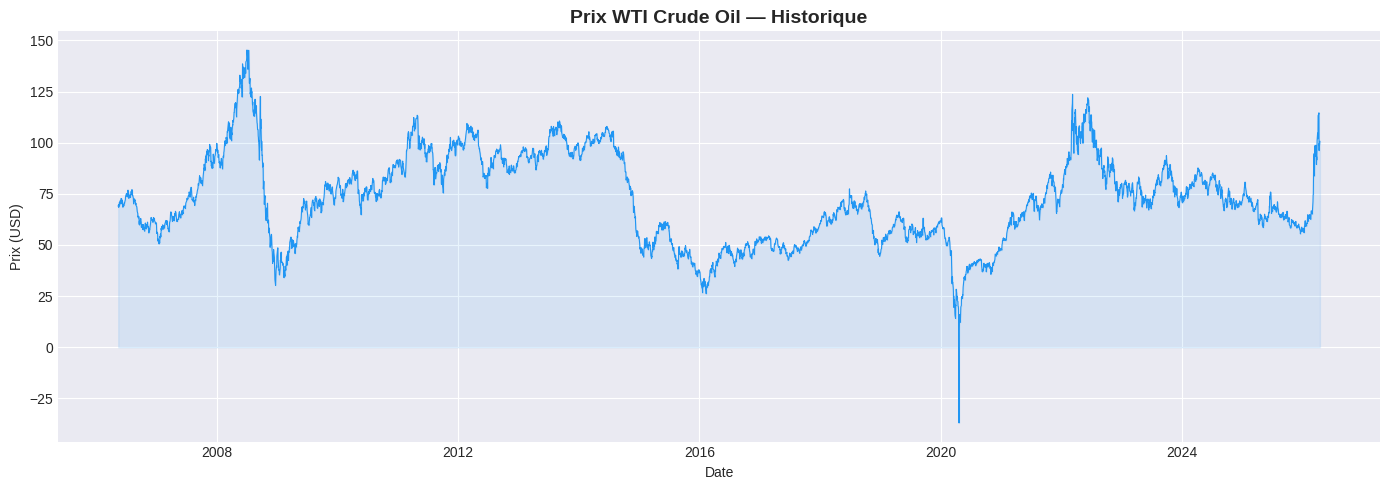

In [3]:
# --- Visualisation du prix WTI ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['price'], linewidth=0.8, color='#2196F3')
ax.set_title('Prix WTI Crude Oil — Historique', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix (USD)')
ax.fill_between(df.index, df['price'], alpha=0.1, color='#2196F3')
plt.tight_layout()
plt.show()

In [4]:
# --- Statistiques descriptives ---
df.describe()

,price
count,5000.000000
mean,72.459970
std,21.465433
min,-36.980000
25%,56.590000
50%,71.345000
75%,88.362500
max,145.310000


## 3. Calcul des Indicateurs Techniques
On calcule les indicateurs classiques utilisés en trading quantitatif :
- **SMA** (Simple Moving Average) — 7, 14, 30, 50 jours
- **EMA** (Exponential Moving Average) — 12, 26 jours
- **RSI** (Relative Strength Index) — 14 jours
- **MACD** (Moving Average Convergence Divergence)
- **Bollinger Bands** — 20 jours
- **ATR** (Average True Range) — 14 jours
- **Returns & Volatilité**

In [5]:
# ============================
# 3.1 Returns & Volatilité
# ============================
df['returns'] = df['price'].pct_change()
df['log_returns'] = np.log(df['price'] / df['price'].shift(1))
df['volatility_7'] = df['returns'].rolling(window=7).std()
df['volatility_21'] = df['returns'].rolling(window=21).std()

# ============================
# 3.2 Moyennes Mobiles (SMA)
# ============================
for window in [7, 14, 30, 50]:
    df[f'sma_{window}'] = df['price'].rolling(window=window).mean()

# ============================
# 3.3 Moyennes Mobiles Exponentielles (EMA)
# ============================
df['ema_12'] = df['price'].ewm(span=12, adjust=False).mean()
df['ema_26'] = df['price'].ewm(span=26, adjust=False).mean()

# ============================
# 3.4 MACD
# ============================
df['macd'] = df['ema_12'] - df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

# ============================
# 3.5 RSI (14 jours)
# ============================
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0.0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi_14'] = compute_rsi(df['price'], 14)

# ============================
# 3.6 Bollinger Bands (20 jours)
# ============================
df['bb_mid'] = df['price'].rolling(window=20).mean()
df['bb_std'] = df['price'].rolling(window=20).std()
df['bb_upper'] = df['bb_mid'] + 2 * df['bb_std']
df['bb_lower'] = df['bb_mid'] - 2 * df['bb_std']
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid']
df['bb_pct'] = (df['price'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

# ============================
# 3.7 ATR (Average True Range)
# ============================
df['high'] = df['price'].rolling(2).max()
df['low'] = df['price'].rolling(2).min()
df['tr'] = df['high'] - df['low']
df['atr_14'] = df['tr'].rolling(window=14).mean()

# ============================
# 3.8 Ratios de prix
# ============================
df['price_to_sma30'] = df['price'] / df['sma_30']
df['price_to_sma50'] = df['price'] / df['sma_50']

# ============================
# 3.9 Momentum
# ============================
df['momentum_5'] = df['price'] / df['price'].shift(5) - 1
df['momentum_10'] = df['price'] / df['price'].shift(10) - 1
df['momentum_20'] = df['price'] / df['price'].shift(20) - 1

print(f"✅ {len(df.columns)} colonnes après feature engineering")
df.tail()

✅ 30 colonnes après feature engineering


,price,returns,log_returns,volatility_7,volatility_21,sma_7,sma_14,sma_30,sma_50,ema_12,ema_26,macd,macd_signal,macd_hist,rsi_14,bb_mid,bb_std,bb_upper,bb_lower,bb_width,bb_pct,high,low,tr,atr_14,price_to_sma30,price_to_sma50,momentum_5,momentum_10,momentum_20
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-07,114.58,0.005000,0.004987,0.044690,0.054405,107.504286,100.976429,90.571333,79.8868,103.838657,94.865033,8.973624,7.932560,1.041063,70.066998,98.3835,8.481200,115.345901,81.421099,0.344822,0.977424,114.58,114.01,0.57,3.305000,1.265080,1.434280,0.094469,0.282660,0.210565
2026-04-08,96.17,-0.160674,-0.175156,0.081300,0.065702,106.777143,100.980000,91.589667,80.6010,102.658864,94.961698,7.697166,7.885482,-0.188315,50.038718,99.0065,7.774824,114.556148,83.456852,0.314114,0.408792,114.58,96.17,18.41,4.612143,1.050009,1.193161,-0.065040,0.032088,0.148847
2026-04-09,99.62,0.035874,0.035245,0.081460,0.060122,106.052857,101.230714,92.733667,81.3526,102.191346,95.306757,6.884589,7.685303,-0.800714,52.580503,99.6475,7.224483,114.096466,85.198534,0.290002,0.499048,99.62,96.17,3.45,4.857857,1.074259,1.224546,-0.022375,0.088624,0.147696
2026-04-10,98.34,-0.012849,-0.012932,0.081352,0.059993,105.407143,101.204286,93.841667,82.0644,101.598831,95.531442,6.067390,7.361720,-1.294331,49.722597,99.7840,7.169766,114.123533,85.444467,0.287411,0.449650,99.62,98.34,1.28,4.763571,1.047935,1.198327,-0.131502,0.022458,0.028553
2026-04-13,100.72,0.024202,0.023914,0.081931,0.056204,105.238571,102.017857,94.967000,82.7834,101.463627,95.915779,5.547847,6.998946,-1.451099,59.540962,99.8960,7.165819,114.227638,85.564362,0.286931,0.528748,100.72,98.34,2.38,4.263571,1.060579,1.216669,-0.116569,-0.005333,0.022746


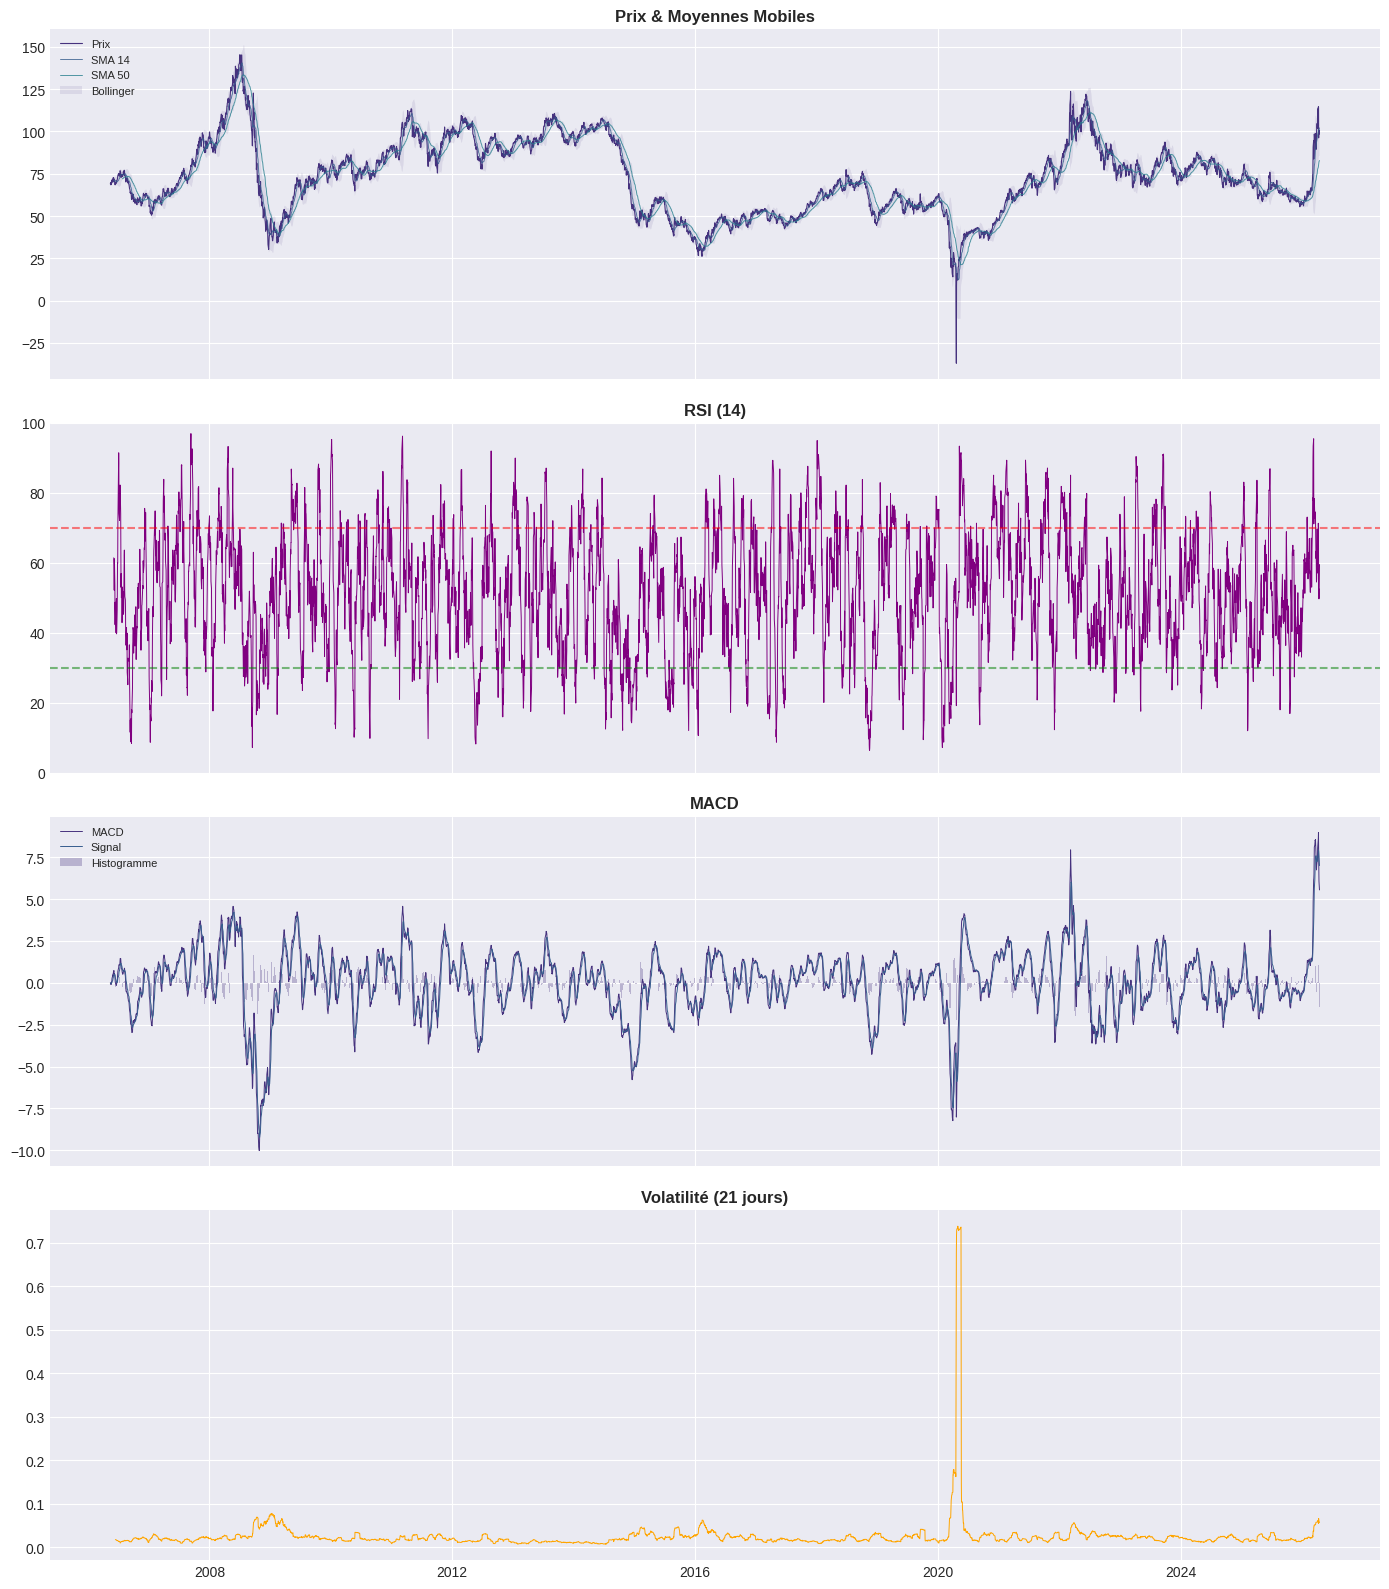

In [6]:
# --- Visualisation des indicateurs clés ---
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Prix + SMA
axes[0].plot(df.index, df['price'], label='Prix', linewidth=0.8)
axes[0].plot(df.index, df['sma_14'], label='SMA 14', linewidth=0.7, alpha=0.8)
axes[0].plot(df.index, df['sma_50'], label='SMA 50', linewidth=0.7, alpha=0.8)
axes[0].fill_between(df.index, df['bb_lower'], df['bb_upper'], alpha=0.1, label='Bollinger')
axes[0].set_title('Prix & Moyennes Mobiles', fontweight='bold')
axes[0].legend(loc='upper left', fontsize=8)

# RSI
axes[1].plot(df.index, df['rsi_14'], color='purple', linewidth=0.7)
axes[1].axhline(70, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('RSI (14)', fontweight='bold')
axes[1].set_ylim(0, 100)

# MACD
axes[2].plot(df.index, df['macd'], label='MACD', linewidth=0.7)
axes[2].plot(df.index, df['macd_signal'], label='Signal', linewidth=0.7)
axes[2].bar(df.index, df['macd_hist'], alpha=0.3, label='Histogramme')
axes[2].set_title('MACD', fontweight='bold')
axes[2].legend(loc='upper left', fontsize=8)

# Volatilité
axes[3].plot(df.index, df['volatility_21'], color='orange', linewidth=0.7)
axes[3].set_title('Volatilité (21 jours)', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Préparation des Features & Target
- **Target** : Direction du prix le lendemain (1 = hausse, 0 = baisse)
- **Features** : Tous les indicateurs techniques calculés

In [ ]:
# --- Définition du target : direction du prix à J+1 ---
df['target'] = (df['price'].shift(-1) > df['price']).astype(int)

# --- Sélection des features ---
FEATURE_COLS = [
    'returns', 'log_returns',
    'volatility_7', 'volatility_21',
    'sma_7', 'sma_14', 'sma_30', 'sma_50',
    'ema_12', 'ema_26',
    'macd', 'macd_signal', 'macd_hist',
    'rsi_14',
    'bb_width', 'bb_pct',
    'atr_14',
    'price_to_sma30', 'price_to_sma50',
    'momentum_5', 'momentum_10', 'momentum_20',
    # NB : les features de sentiment NLP (sentiment_score, sentiment_ma_7,
    # news_volume, news_volume_ma_7) sont ajoutees a la section 5 ci-dessous,
    # qui reconstruit df_model et le split avec ces colonnes.
]

# --- Nettoyage des NaN (causés par les rolling windows) ---
df_model = df[FEATURE_COLS + ['target', 'price']].dropna()
print(f"\U0001F4CF Dataset modèle : {len(df_model)} lignes, {len(FEATURE_COLS)} features")
print(f"\U0001F4CA Distribution target : \n{df_model['target'].value_counts(normalize=True).round(3)}")

In [8]:
# --- Split temporel (pas de shuffle pour les séries temporelles !) ---
# 80% train / 20% test
split_idx = int(len(df_model) * 0.8)

X_train = df_model[FEATURE_COLS].iloc[:split_idx]
X_test  = df_model[FEATURE_COLS].iloc[split_idx:]
y_train = df_model['target'].iloc[:split_idx]
y_test  = df_model['target'].iloc[split_idx:]

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"🔹 Train : {len(X_train)} ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"🔹 Test  : {len(X_test)} ({X_test.index.min().date()} → {X_test.index.max().date()})")

🔹 Train : 3959 (2006-07-27 → 2022-04-18)
🔹 Test  : 990 (2022-04-19 → 2026-04-13)


## 5. 📰 Intégration du Sentiment NLP

On enrichit les features avec le **score de sentiment** issu du pipeline NLP (`ai/nlp/`), agrégé par jour dans `sentiment_wti.parquet`.

Le sentiment réel est **épars** (news scrapées en direct, sans archives). On le rend exploitable comme feature ML par : forward-fill décroissant vers 0, moyenne mobile 7 jours, et volume d'articles. Une news de week-end est rattachée au prochain jour de trading.

Ces colonnes sont ajoutées à `FEATURE_COLS`, puis `df_model` et le split sont **reconstruits** pour que tous les modèles en aval (RF, XGBoost, CV, walk-forward) utilisent le sentiment.

> ⚠️ Vu la sparsité, l'impact du sentiment se concentre sur la période récente. C'est attendu et affiché honnêtement.

In [ ]:
# ================================================================
# INTÉGRATION DU SENTIMENT NLP COMME FEATURE
# ================================================================
from pathlib import Path

SENTIMENT_PATH = Path("../../scraping/src/data/processed/sentiment_wti.parquet")
SENTIMENT_DECAY = 0.85
SENTIMENT_COLS = ['sentiment_score', 'sentiment_ma_7', 'news_volume', 'news_volume_ma_7']


def build_sentiment_features(index, sentiment_path=SENTIMENT_PATH, decay=SENTIMENT_DECAY):
    """Features de sentiment alignées sur les dates de trading (snap au jour suivant)."""
    out = pd.DataFrame(0.0, index=index, columns=SENTIMENT_COLS)
    if not sentiment_path.exists():
        print(f"sentiment introuvable ({sentiment_path}) - features neutres.")
        return out

    sen = pd.read_parquet(sentiment_path)
    sen['date'] = pd.to_datetime(sen['date']).astype('datetime64[ns]')
    sen = sen.sort_values('date')
    trading = pd.DataFrame({'date': index.astype('datetime64[ns]'),
                            'trade_day': index.astype('datetime64[ns]')})
    snapped = pd.merge_asof(sen, trading, on='date', direction='forward')
    agg = (snapped.dropna(subset=['trade_day'])
           .groupby('trade_day')
           .agg(sentiment_score=('sentiment_score', 'mean'),
                n_articles=('n_articles', 'sum')))

    raw_score = agg['sentiment_score'].reindex(index)
    raw_volume = agg['n_articles'].reindex(index)

    decayed, last_val, days_since = [], 0.0, None
    for val in raw_score:
        if pd.notna(val):
            last_val, days_since = float(val), 0
        elif days_since is not None:
            days_since += 1
            last_val *= decay
        decayed.append(last_val if days_since is not None else 0.0)

    out['sentiment_score'] = decayed
    out['sentiment_ma_7'] = out['sentiment_score'].rolling(7, min_periods=1).mean()
    out['news_volume'] = raw_volume.fillna(0.0).clip(lower=0.0)
    out['news_volume_ma_7'] = out['news_volume'].rolling(7, min_periods=1).mean()
    return out


# 1. Joindre les features de sentiment a df
df = df.join(build_sentiment_features(df.index))

# 2. Etendre FEATURE_COLS (sans doublon si re-execution)
for col in SENTIMENT_COLS:
    if col not in FEATURE_COLS:
        FEATURE_COLS.append(col)

# 3. Reconstruire df_model + split temporel + normalisation
df_model = df[FEATURE_COLS + ['target', 'price']].dropna()
split_idx = int(len(df_model) * 0.8)
X_train = df_model[FEATURE_COLS].iloc[:split_idx]
X_test  = df_model[FEATURE_COLS].iloc[split_idx:]
y_train = df_model['target'].iloc[:split_idx]
y_test  = df_model['target'].iloc[split_idx:]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. Diagnostic honnete de la couverture
n_news = int((df['news_volume'] > 0).sum())
n_nonzero = int((df['sentiment_score'].abs() > 1e-6).sum())
print(f"Sentiment NLP integre : {len(SENTIMENT_COLS)} features, {len(df_model)} lignes, {len(FEATURE_COLS)} features au total")
print(f"Couverture : {n_news} jours avec news / {len(df)} ; sentiment non-neutre sur {n_nonzero} jours")
if n_nonzero < 10:
    print("ATTENTION : sentiment exploitable surtout en periode recente ; apport NLP quasi nul sur cet historique.")
print(f"Train : {len(X_train)} ({X_train.index.min().date()} -> {X_train.index.max().date()})")
print(f"Test  : {len(X_test)} ({X_test.index.min().date()} -> {X_test.index.max().date()})")
df_model[SENTIMENT_COLS].tail()

## 6. Fonctions Utilitaires

In [9]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    """Affiche les métriques de classification et la matrice de confusion."""
    print(f"\n{'='*50}")
    print(f"  📈 Résultats — {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Baisse','Hausse']))

    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Baisse','Hausse'], yticklabels=['Baisse','Hausse'])
    ax.set_title(f'Matrice de Confusion — {name}', fontweight='bold')
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')
    plt.tight_layout()
    plt.show()
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }

## 7. Modèle — Random Forest 🌲

In [ ]:
# --- Entraînement Random Forest (fortement régularisé) ---
# Prédire la direction J+1 du pétrole est proche du bruit. Sans régularisation,
# le modèle mémorise le train et s'effondre en test (sous la baseline). Ces
# hyperparamètres réduisent l'écart train/test pour des résultats honnêtes.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_split=60,
    min_samples_leaf=30,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

baseline_acc = max(y_test.mean(), 1 - y_test.mean())
acc_train = (rf_model.predict(X_train_scaled) == y_train).mean()
acc_test = (rf_pred == y_test).mean()
print(f"Accuracy train : {acc_train:.3f} | test : {acc_test:.3f} | ecart : {acc_train - acc_test:+.3f}")
print(f"Baseline (classe majoritaire) : {baseline_acc:.3f}")
if acc_test < baseline_acc:
    print("Note : le modele ne bat pas la baseline en test - la direction quotidienne du petrole est tres difficile a predire.")

rf_metrics = evaluate_model("Random Forest", y_test, rf_pred, rf_proba)

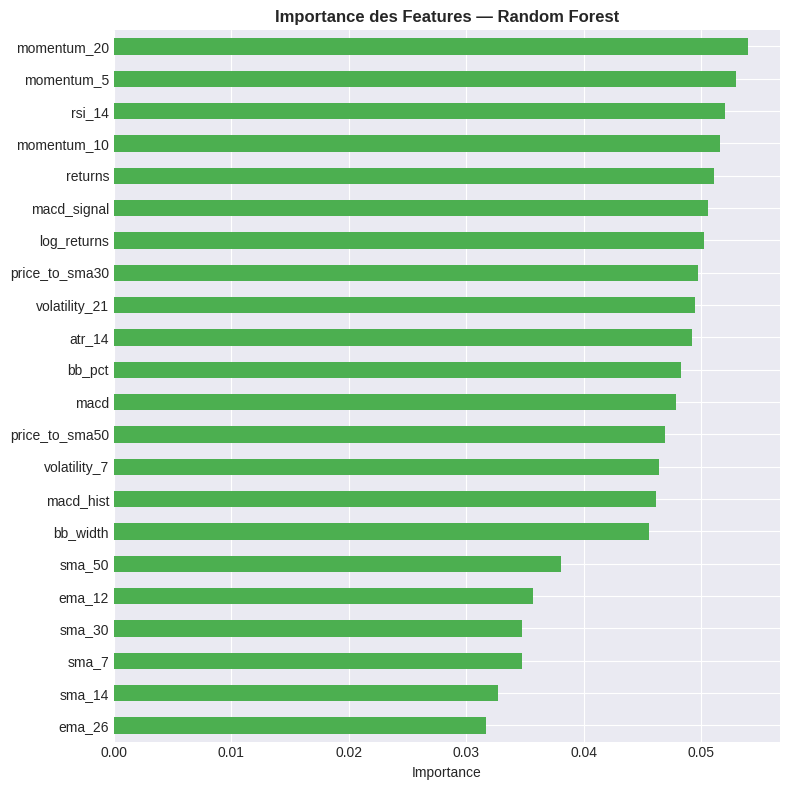

In [11]:
# --- Feature Importance (Random Forest) ---
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
feat_imp.plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_title('Importance des Features — Random Forest', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Modèle — XGBoost 🚀

In [ ]:
# --- Entraînement XGBoost (fortement régularisé) ---
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2.0,
    min_child_weight=10,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

acc_train = (xgb_model.predict(X_train_scaled) == y_train).mean()
acc_test = (xgb_pred == y_test).mean()
print(f"Accuracy train : {acc_train:.3f} | test : {acc_test:.3f} | ecart : {acc_train - acc_test:+.3f}")
print(f"Baseline (classe majoritaire) : {max(y_test.mean(), 1 - y_test.mean()):.3f}")

xgb_metrics = evaluate_model("XGBoost", y_test, xgb_pred, xgb_proba)

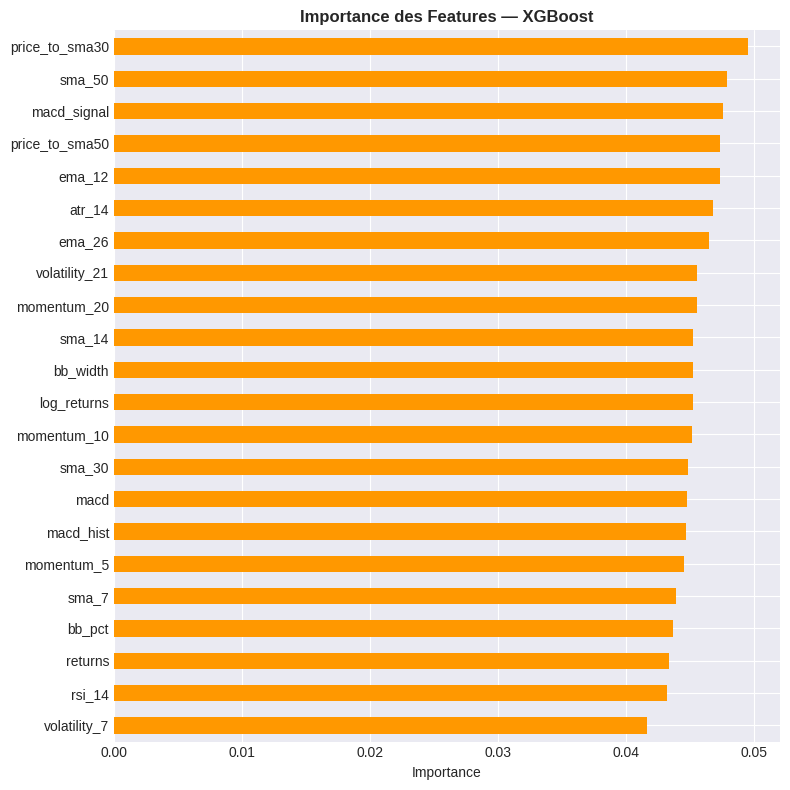

In [13]:
# --- Feature Importance (XGBoost) ---
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
xgb_imp.plot(kind='barh', ax=ax, color='#FF9800')
ax.set_title('Importance des Features — XGBoost', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Comparaison des Modèles

               accuracy  precision  recall      f1
model                                             
Random Forest    0.4677     0.4876  0.6145  0.5437
XGBoost          0.4929     0.5077  0.5793  0.5411


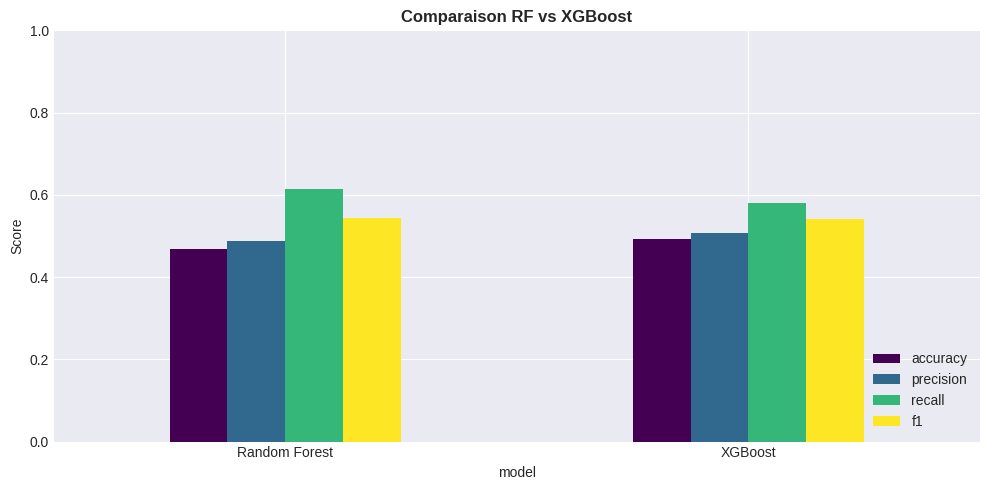

In [14]:
# --- Tableau comparatif ---
results_df = pd.DataFrame([rf_metrics, xgb_metrics]).set_index('model')
print(results_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(kind='bar', ax=ax, rot=0, colormap='viridis')
ax.set_title('Comparaison RF vs XGBoost', fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 10. Backtesting 📊
Simulation de trading basée sur les prédictions des modèles.
- **Signal = 1** (Hausse prédite) → on achète
- **Signal = 0** (Baisse prédite) → on reste cash
- Comparaison avec la stratégie Buy & Hold

In [15]:
def backtest_strategy(df_bt, predictions, proba, model_name, threshold=0.5):
    """
    Backtesting d'une stratégie ML.
    - positions basées sur les prédictions (avec seuil de confiance)
    - calcul du rendement cumulé, max drawdown, sharpe ratio
    """
    bt = df_bt.copy()
    bt['signal'] = (proba >= threshold).astype(int)
    bt['strategy_returns'] = bt['signal'] * bt['returns']
    bt['cumulative_market'] = (1 + bt['returns']).cumprod()
    bt['cumulative_strategy'] = (1 + bt['strategy_returns']).cumprod()

    # Métriques
    total_return_market = bt['cumulative_market'].iloc[-1] - 1
    total_return_strategy = bt['cumulative_strategy'].iloc[-1] - 1

    # Sharpe Ratio (annualisé)
    sharpe = bt['strategy_returns'].mean() / bt['strategy_returns'].std() * np.sqrt(252)

    # Max Drawdown
    cummax = bt['cumulative_strategy'].cummax()
    drawdown = (bt['cumulative_strategy'] - cummax) / cummax
    max_dd = drawdown.min()

    # Win rate
    trades = bt[bt['signal'] == 1]
    win_rate = (trades['strategy_returns'] > 0).mean() if len(trades) > 0 else 0

    print(f"\n{'='*55}")
    print(f"  📊 Backtesting — {model_name} (seuil={threshold})")
    print(f"{'='*55}")
    print(f"  Rendement Marché (B&H)  : {total_return_market:+.2%}")
    print(f"  Rendement Stratégie     : {total_return_strategy:+.2%}")
    print(f"  Sharpe Ratio (ann.)     : {sharpe:.3f}")
    print(f"  Max Drawdown            : {max_dd:.2%}")
    print(f"  Win Rate                : {win_rate:.2%}")
    print(f"  Nb Trades (jours long)  : {bt['signal'].sum()} / {len(bt)}")

    return bt, {
        'model': model_name,
        'return_market': total_return_market,
        'return_strategy': total_return_strategy,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'win_rate': win_rate,
        'nb_trades': int(bt['signal'].sum())
    }

In [16]:
# --- Préparer le dataframe de backtest (période test uniquement) ---
df_backtest = df_model.iloc[split_idx:].copy()
df_backtest['returns'] = df_backtest['price'].pct_change().fillna(0)

# --- Backtesting Random Forest ---
bt_rf, bt_rf_metrics = backtest_strategy(df_backtest, rf_pred, rf_proba, "Random Forest", threshold=0.5)

# --- Backtesting XGBoost ---
bt_xgb, bt_xgb_metrics = backtest_strategy(df_backtest, xgb_pred, xgb_proba, "XGBoost", threshold=0.5)


  📊 Backtesting — Random Forest (seuil=0.5)
  Rendement Marché (B&H)  : -1.77%
  Rendement Stratégie     : +5.57%
  Sharpe Ratio (ann.)     : 0.185
  Max Drawdown            : -47.24%
  Win Rate                : 51.24%
  Nb Trades (jours long)  : 644 / 990

  📊 Backtesting — XGBoost (seuil=0.5)
  Rendement Marché (B&H)  : -1.77%
  Rendement Stratégie     : -20.47%
  Sharpe Ratio (ann.)     : -0.068
  Max Drawdown            : -56.08%
  Win Rate                : 47.00%
  Nb Trades (jours long)  : 583 / 990


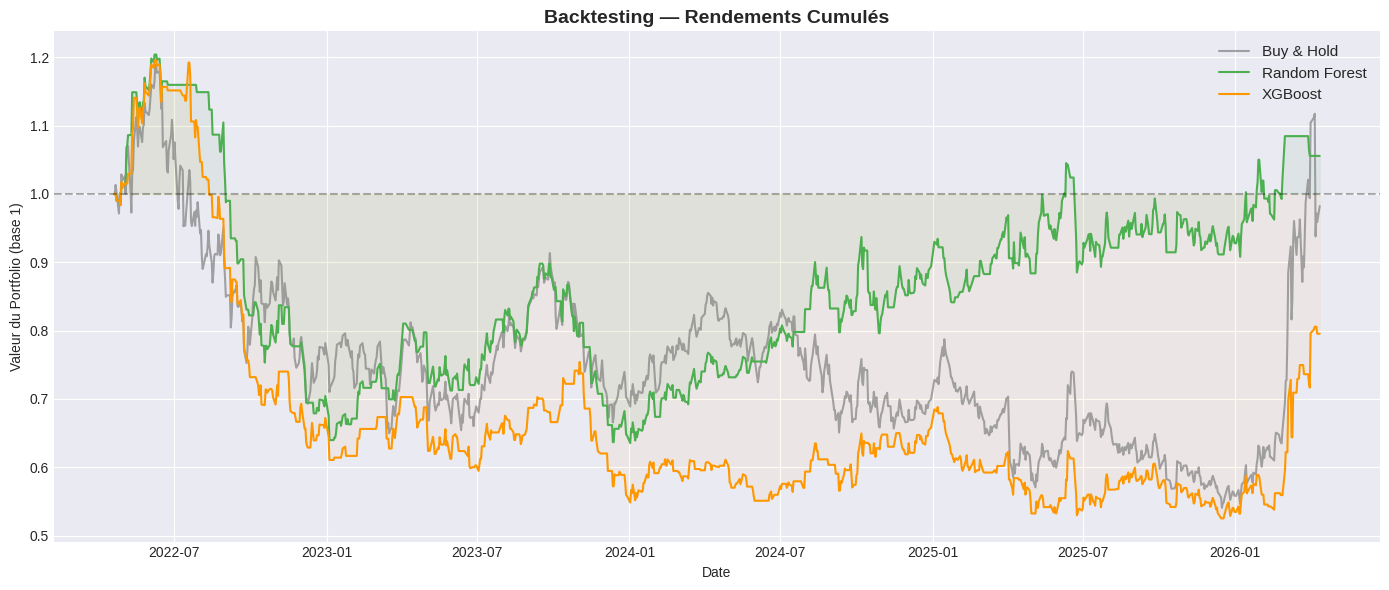

In [17]:
# --- Graphique des rendements cumulés ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt_rf.index, bt_rf['cumulative_market'], label='Buy & Hold', linewidth=1.5, color='gray', alpha=0.7)
ax.plot(bt_rf.index, bt_rf['cumulative_strategy'], label='Random Forest', linewidth=1.5, color='#4CAF50')
ax.plot(bt_xgb.index, bt_xgb['cumulative_strategy'], label='XGBoost', linewidth=1.5, color='#FF9800')
ax.axhline(1, color='black', linestyle='--', alpha=0.3)
ax.set_title('Backtesting — Rendements Cumulés', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Valeur du Portfolio (base 1)')
ax.legend(fontsize=11)
ax.fill_between(bt_rf.index, bt_rf['cumulative_strategy'], 1, alpha=0.05, color='green')
ax.fill_between(bt_xgb.index, bt_xgb['cumulative_strategy'], 1, alpha=0.05, color='orange')
plt.tight_layout()
plt.show()

In [18]:
# --- Résumé final du backtesting ---
bt_summary = pd.DataFrame([bt_rf_metrics, bt_xgb_metrics]).set_index('model')
print("\n📋 Résumé Backtesting :")
print(bt_summary.round(4).to_string())


📋 Résumé Backtesting :
               return_market  return_strategy  sharpe  max_drawdown  win_rate  nb_trades
model                                                                                   
Random Forest        -0.0177           0.0557  0.1847       -0.4724    0.5124        644
XGBoost              -0.0177          -0.2047 -0.0677       -0.5608    0.4700        583


## 11. Validation Croisée (Time Series Split)

In [19]:
# --- Cross-validation avec TimeSeriesSplit ---
tscv = TimeSeriesSplit(n_splits=5)
X_all = scaler.fit_transform(df_model[FEATURE_COLS])
y_all = df_model['target'].values

cv_results = {'Random Forest': [], 'XGBoost': []}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all)):
    X_tr, X_val = X_all[train_idx], X_all[val_idx]
    y_tr, y_val = y_all[train_idx], y_all[val_idx]

    # RF
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    cv_results['Random Forest'].append(accuracy_score(y_val, rf.predict(X_val)))

    # XGB
    xgb = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05,
                         random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
    xgb.fit(X_tr, y_tr)
    cv_results['XGBoost'].append(accuracy_score(y_val, xgb.predict(X_val)))

    print(f"  Fold {fold+1} — RF: {cv_results['Random Forest'][-1]:.4f} | XGB: {cv_results['XGBoost'][-1]:.4f}")

print(f"\n📊 Moyenne CV — RF: {np.mean(cv_results['Random Forest']):.4f} | XGB: {np.mean(cv_results['XGBoost']):.4f}")

  Fold 1 — RF: 0.5146 | XGB: 0.5206
  Fold 2 — RF: 0.4915 | XGB: 0.5012
  Fold 3 — RF: 0.4939 | XGB: 0.4891
  Fold 4 — RF: 0.5000 | XGB: 0.4903
  Fold 5 — RF: 0.4939 | XGB: 0.4806

📊 Moyenne CV — RF: 0.4988 | XGB: 0.4964


## 12. ⚙️ Optimisation des Hyperparamètres
Recherche systématique des meilleurs hyperparamètres via **GridSearchCV** et **RandomizedSearchCV** avec un split temporel.

### 12.1 GridSearchCV — Random Forest

Fitting 3 folds for each of 81 candidates, totalling 243 fits


/mnt/data/insea/s4/projetTrading/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/mnt/data/insea/s4/projetTrading/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/mnt/data/insea/s4/projetTrading/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/mnt/data/insea/s4/projet


🏆 Meilleurs paramètres RF :
   max_depth: 5
   min_samples_leaf: 3
   min_samples_split: 20
   n_estimators: 200
   Best F1 (CV): 0.5982

  📈 Résultats — RF Optimisé
  Accuracy  : 0.4596
  Precision : 0.4810
  Recall    : 0.5930
  F1-Score  : 0.5311

              precision    recall  f1-score   support

      Baisse       0.42      0.32      0.36       479
      Hausse       0.48      0.59      0.53       511

    accuracy                           0.46       990
   macro avg       0.45      0.46      0.45       990
weighted avg       0.45      0.46      0.45       990



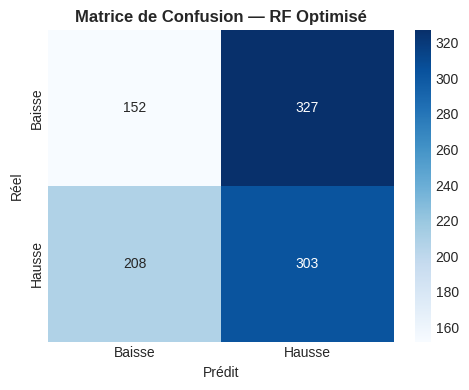

In [20]:
# --- GridSearchCV pour Random Forest ---
# On utilise TimeSeriesSplit pour respecter l'ordre temporel
tscv_opt = TimeSeriesSplit(n_splits=3)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [3, 5, 10],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid=rf_param_grid,
    cv=tscv_opt,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_scaled, y_train)

print(f"\n🏆 Meilleurs paramètres RF :")
for k, v in rf_grid.best_params_.items():
    print(f"   {k}: {v}")
print(f"   Best F1 (CV): {rf_grid.best_score_:.4f}")

# Évaluation sur le test set
rf_opt_pred = rf_grid.best_estimator_.predict(X_test_scaled)
rf_opt_proba = rf_grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
rf_opt_metrics = evaluate_model("RF Optimisé", y_test, rf_opt_pred, rf_opt_proba)

### 12.2 RandomizedSearchCV — XGBoost
> RandomizedSearch est plus efficace que GridSearch quand l'espace de recherche est grand.

Fitting 3 folds for each of 50 candidates, totalling 150 fits

🏆 Meilleurs paramètres XGBoost :
   colsample_bytree: 0.5504
   learning_rate: 0.0136
   max_depth: 5
   min_child_weight: 2
   n_estimators: 134
   reg_alpha: 0.3366
   reg_lambda: 1.8114
   subsample: 0.7542
   Best F1 (CV): 0.5956

  📈 Résultats — XGB Optimisé
  Accuracy  : 0.4697
  Precision : 0.4907
  Recall    : 0.7202
  F1-Score  : 0.5837

              precision    recall  f1-score   support

      Baisse       0.40      0.20      0.27       479
      Hausse       0.49      0.72      0.58       511

    accuracy                           0.47       990
   macro avg       0.45      0.46      0.43       990
weighted avg       0.45      0.47      0.43       990



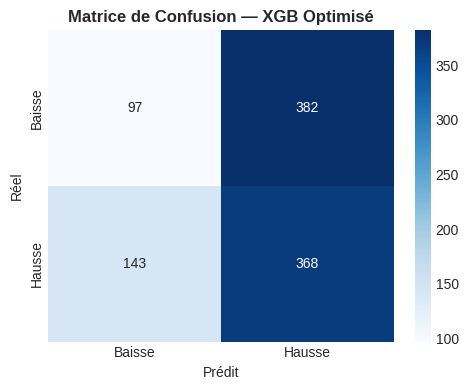

In [21]:
# --- RandomizedSearchCV pour XGBoost ---
from scipy.stats import randint, uniform

xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 2),
    'min_child_weight': randint(1, 10),
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=50,  # 50 combinaisons aléatoires
    cv=tscv_opt,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
xgb_random.fit(X_train_scaled, y_train)

print(f"\n🏆 Meilleurs paramètres XGBoost :")
for k, v in xgb_random.best_params_.items():
    print(f"   {k}: {round(v, 4) if isinstance(v, float) else v}")
print(f"   Best F1 (CV): {xgb_random.best_score_:.4f}")

# Évaluation sur le test set
xgb_opt_pred = xgb_random.best_estimator_.predict(X_test_scaled)
xgb_opt_proba = xgb_random.best_estimator_.predict_proba(X_test_scaled)[:, 1]
xgb_opt_metrics = evaluate_model("XGB Optimisé", y_test, xgb_opt_pred, xgb_opt_proba)


📋 Comparaison avant/après optimisation :
               accuracy  precision  recall      f1
model                                             
Random Forest    0.4677     0.4876  0.6145  0.5437
RF Optimisé      0.4596     0.4810  0.5930  0.5311
XGBoost          0.4929     0.5077  0.5793  0.5411
XGB Optimisé     0.4697     0.4907  0.7202  0.5837


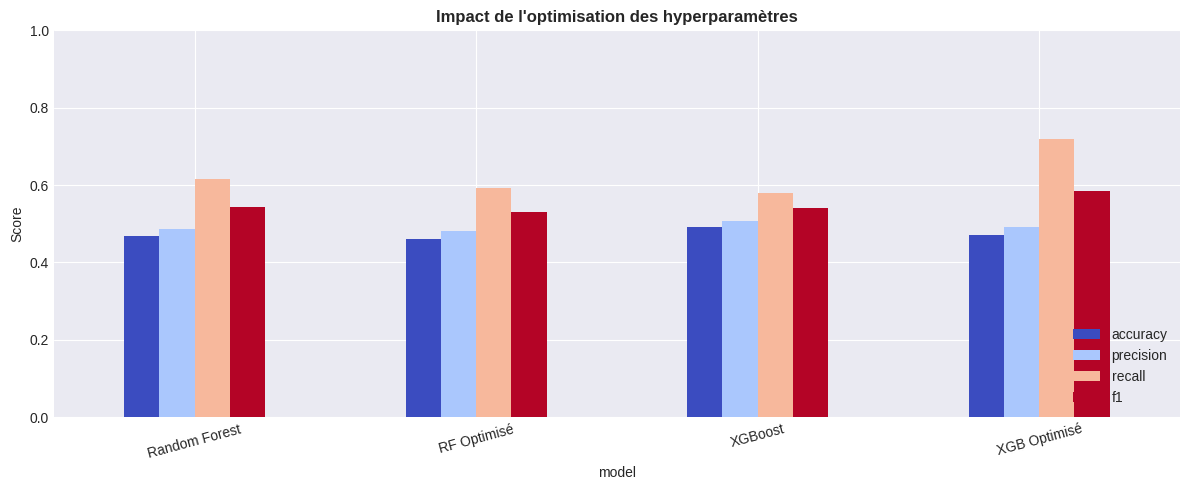

In [27]:
# --- Comparaison avant / après optimisation ---
all_metrics = pd.DataFrame([rf_metrics, rf_opt_metrics, xgb_metrics, xgb_opt_metrics]).set_index('model')
print("\n📋 Comparaison avant/après optimisation :")
print(all_metrics.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
all_metrics.plot(kind='bar', ax=ax, rot=15, colormap='coolwarm')
ax.set_title("Impact de l'optimisation des hyperparamètres", fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 13. 💰 Gestion du Risque — Stop-Loss & Position Sizing
Une stratégie profitable ne suffit pas — il faut gérer le **risque** pour survivre aux périodes de pertes.

- **Stop-Loss** : Sortir automatiquement si la perte dépasse un seuil
- **Take-Profit** : Sécuriser les gains à un seuil prédéfini
- **Position Sizing (Kelly)** : Ajuster la taille de position selon la confiance du modèle

In [28]:
def backtest_with_risk_management(
    df_bt, proba, model_name,
    threshold=0.5,
    stop_loss=-0.03,     # -3% stop loss
    take_profit=0.05,    # +5% take profit
    use_kelly=False
):
    """
    Backtesting avancé avec gestion du risque.
    - Stop-loss et take-profit par trade
    - Position sizing optionnel via critère de Kelly
    """
    bt = df_bt.copy()
    bt['signal'] = (proba >= threshold).astype(int)
    bt['returns'] = bt['price'].pct_change().fillna(0)

    # --- Kelly Criterion pour le position sizing ---
    # f* = (p * b - q) / b   où p=win_rate, q=1-p, b=gain_moyen/perte_moyenne
    if use_kelly:
        # Calculer sur une fenêtre glissante de 60 jours
        kelly_fractions = []
        for i in range(len(bt)):
            if i < 60:
                kelly_fractions.append(0.5)  # Défaut avant suffisamment de données
                continue
            window = bt['returns'].iloc[max(0,i-60):i]
            wins = window[window > 0]
            losses = window[window < 0]
            if len(wins) == 0 or len(losses) == 0:
                kelly_fractions.append(0.5)
                continue
            p = len(wins) / len(window)
            b = wins.mean() / abs(losses.mean())
            kelly = (p * b - (1 - p)) / b
            kelly = np.clip(kelly, 0, 1)  # Borner entre 0 et 1
            kelly_fractions.append(kelly * 0.5)  # Demi-Kelly (plus conservateur)
        bt['kelly_fraction'] = kelly_fractions
        bt['position_size'] = bt['signal'] * bt['kelly_fraction']
    else:
        bt['position_size'] = bt['signal'].astype(float)

    # --- Appliquer Stop-Loss & Take-Profit ---
    adjusted_returns = []
    for i in range(len(bt)):
        r = bt['returns'].iloc[i] * bt['position_size'].iloc[i]
        if r < stop_loss:
            r = stop_loss  # Stop-loss déclenché
        elif r > take_profit:
            r = take_profit  # Take-profit déclenché
        adjusted_returns.append(r)

    bt['strategy_returns'] = adjusted_returns
    bt['cumulative_strategy'] = (1 + bt['strategy_returns']).cumprod()
    bt['cumulative_market'] = (1 + bt['returns']).cumprod()

    # --- Métriques ---
    total_ret = bt['cumulative_strategy'].iloc[-1] - 1
    sharpe = bt['strategy_returns'].mean() / bt['strategy_returns'].std() * np.sqrt(252) if bt['strategy_returns'].std() > 0 else 0
    cummax = bt['cumulative_strategy'].cummax()
    max_dd = ((bt['cumulative_strategy'] - cummax) / cummax).min()
    trades = bt[bt['signal'] == 1]
    win_rate = (trades['strategy_returns'] > 0).mean() if len(trades) > 0 else 0
    stop_triggers = sum(1 for r in adjusted_returns if r == stop_loss and bt['signal'].iloc[adjusted_returns.index(r)] == 1)

    sizing_label = "Kelly" if use_kelly else "Fixe"
    print(f"\n{'='*60}")
    print(f"  💰 {model_name} — SL={stop_loss:.1%} / TP={take_profit:.1%} / Sizing={sizing_label}")
    print(f"{'='*60}")
    print(f"  Rendement Stratégie : {total_ret:+.2%}")
    print(f"  Sharpe Ratio        : {sharpe:.3f}")
    print(f"  Max Drawdown        : {max_dd:.2%}")
    print(f"  Win Rate            : {win_rate:.2%}")

    return bt, {
        'model': f"{model_name} (SL/TP/{'Kelly' if use_kelly else 'Fix'})",
        'return': total_ret, 'sharpe': sharpe,
        'max_drawdown': max_dd, 'win_rate': win_rate
    }

In [ ]:
# --- Backtesting avec Risk Management ---
df_bt_rm = df_model.iloc[split_idx:].copy()

# Utiliser le meilleur modèle optimisé (XGBoost)
best_proba = xgb_random.best_estimator_.predict_proba(X_test_scaled)[:, 1]

# Scénario 1 : Sans gestion du risque
_, rm_base = backtest_with_risk_management(
    df_bt_rm, best_proba, "XGB Optimisé",
    stop_loss=-1.0, take_profit=1.0, use_kelly=False
)

# Scénario 2 : Avec Stop-Loss & Take-Profit
_, rm_sltp = backtest_with_risk_management(
    df_bt_rm, best_proba, "XGB + SL/TP",
    stop_loss=-0.02, take_profit=0.04, use_kelly=False
)

# Scénario 3 : Avec Kelly Criterion
bt_kelly, rm_kelly = backtest_with_risk_management(
    df_bt_rm, best_proba, "XGB + Kelly",
    stop_loss=-0.02, take_profit=0.04, use_kelly=True
)


📋 Comparaison des stratégies de gestion du risque :
                           return  sharpe  max_drawdown  win_rate
model                                                            
XGB Optimisé (SL/TP/Fix)  -0.2042 -0.0509       -0.4400    0.4987
XGB + SL/TP (SL/TP/Fix)    2.3035  1.4210       -0.1462    0.4987
XGB + Kelly (SL/TP/Kelly) -0.0650 -0.4369       -0.0980    0.1787


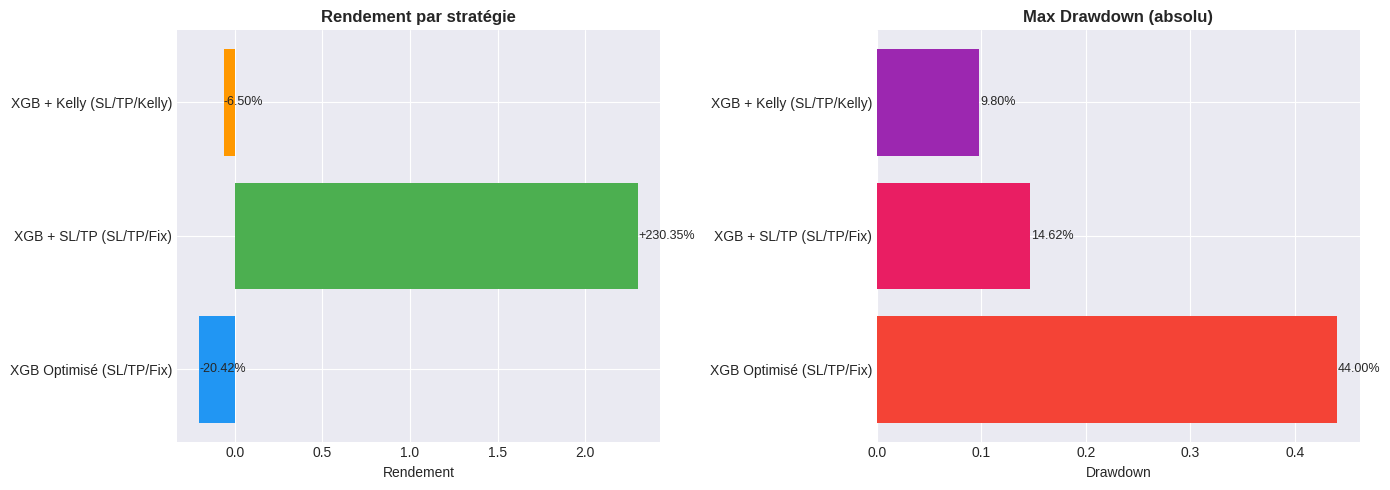

In [30]:
# --- Comparaison des stratégies de risque ---
rm_df = pd.DataFrame([rm_base, rm_sltp, rm_kelly]).set_index('model')
print("\n📋 Comparaison des stratégies de gestion du risque :")
print(rm_df.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rendement vs Drawdown
ax = axes[0]
ax.barh(rm_df.index, rm_df['return'], color=['#2196F3','#4CAF50','#FF9800'])
ax.set_title('Rendement par stratégie', fontweight='bold')
ax.set_xlabel('Rendement')
for i, v in enumerate(rm_df['return']):
    ax.text(v + 0.001, i, f"{v:+.2%}", va='center', fontsize=9)

ax = axes[1]
ax.barh(rm_df.index, rm_df['max_drawdown'].abs(), color=['#f44336','#e91e63','#9c27b0'])
ax.set_title('Max Drawdown (absolu)', fontweight='bold')
ax.set_xlabel('Drawdown')
for i, v in enumerate(rm_df['max_drawdown'].abs()):
    ax.text(v + 0.001, i, f"{v:.2%}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 14. 🔄 Walk-Forward Optimization
Validation la plus **robuste** pour les séries temporelles :
- On découpe l'historique en fenêtres glissantes
- À chaque étape : **entraîner** sur la fenêtre passée, **prédire** la fenêtre suivante
- On ré-optimise les hyperparamètres à chaque étape (adaptatif)

```
Fenêtre 1: [==Train==][Test].................
Fenêtre 2: ...[==Train==][Test].............
Fenêtre 3: ......[==Train==][Test]..........
...et ainsi de suite
```

In [31]:
def walk_forward_optimization(
    df_data, feature_cols, train_window=500, test_window=100, step=100
):
    """
    Walk-Forward Optimization.
    - train_window : nombre de jours d'entraînement
    - test_window  : nombre de jours de test
    - step         : décalage entre chaque fenêtre
    """
    results = []
    all_predictions = []
    all_actuals = []
    all_dates = []

    n = len(df_data)
    start = 0
    fold = 0

    while start + train_window + test_window <= n:
        fold += 1
        train_end = start + train_window
        test_end = train_end + test_window

        # Split
        X_tr = df_data[feature_cols].iloc[start:train_end]
        y_tr = df_data['target'].iloc[start:train_end]
        X_te = df_data[feature_cols].iloc[train_end:test_end]
        y_te = df_data['target'].iloc[train_end:test_end]
        dates_te = df_data.index[train_end:test_end]

        # Normalisation
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)

        # Entraînement XGBoost (on peut aussi faire un mini GridSearch ici)
        model = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, use_label_encoder=False,
            eval_metric='logloss', n_jobs=-1
        )
        model.fit(X_tr_s, y_tr)
        preds = model.predict(X_te_s)
        acc = accuracy_score(y_te, preds)

        results.append({
            'fold': fold,
            'train_start': df_data.index[start].date(),
            'train_end': df_data.index[train_end-1].date(),
            'test_start': dates_te[0].date(),
            'test_end': dates_te[-1].date(),
            'accuracy': acc,
            'f1': f1_score(y_te, preds),
            'n_train': len(X_tr),
            'n_test': len(X_te)
        })

        all_predictions.extend(preds)
        all_actuals.extend(y_te.values)
        all_dates.extend(dates_te)

        start += step

    results_df = pd.DataFrame(results)
    overall_acc = accuracy_score(all_actuals, all_predictions)
    overall_f1 = f1_score(all_actuals, all_predictions)

    print(f"\n{'='*60}")
    print(f"  🔄 Walk-Forward Optimization — {fold} fenêtres")
    print(f"{'='*60}")
    print(f"  Train window : {train_window} jours")
    print(f"  Test window  : {test_window} jours")
    print(f"  Step         : {step} jours")
    print(f"  Accuracy globale : {overall_acc:.4f}")
    print(f"  F1-Score global  : {overall_f1:.4f}")

    return results_df, all_predictions, all_actuals, all_dates

In [32]:
# --- Exécution Walk-Forward ---
wf_results, wf_preds, wf_actuals, wf_dates = walk_forward_optimization(
    df_model, FEATURE_COLS,
    train_window=500,   # ~2 ans d'entraînement
    test_window=100,    # ~4-5 mois de test
    step=100            # Décaler de 100 jours à chaque étape
)

print("\n📊 Détail par fenêtre :")
print(wf_results.to_string(index=False))


  🔄 Walk-Forward Optimization — 44 fenêtres
  Train window : 500 jours
  Test window  : 100 jours
  Step         : 100 jours
  Accuracy globale : 0.5070
  F1-Score global  : 0.5187

📊 Détail par fenêtre :
 fold train_start  train_end test_start   test_end  accuracy       f1  n_train  n_test
    1  2006-07-27 2008-07-22 2008-07-23 2008-12-11      0.46 0.509091      500     100
    2  2006-12-19 2008-12-11 2008-12-12 2009-05-07      0.53 0.534653      500     100
    3  2007-05-15 2009-05-07 2009-05-08 2009-09-29      0.46 0.386364      500     100
    4  2007-10-05 2009-09-29 2009-09-30 2010-02-23      0.46 0.526316      500     100
    5  2008-02-29 2010-02-23 2010-02-24 2010-07-16      0.54 0.557692      500     100
    6  2008-07-23 2010-07-16 2010-07-19 2010-12-07      0.60 0.555556      500     100
    7  2008-12-12 2010-12-07 2010-12-08 2011-05-02      0.46 0.068966      500     100
    8  2009-05-08 2011-05-02 2011-05-03 2011-09-22      0.58 0.562500      500     100
    9  2009

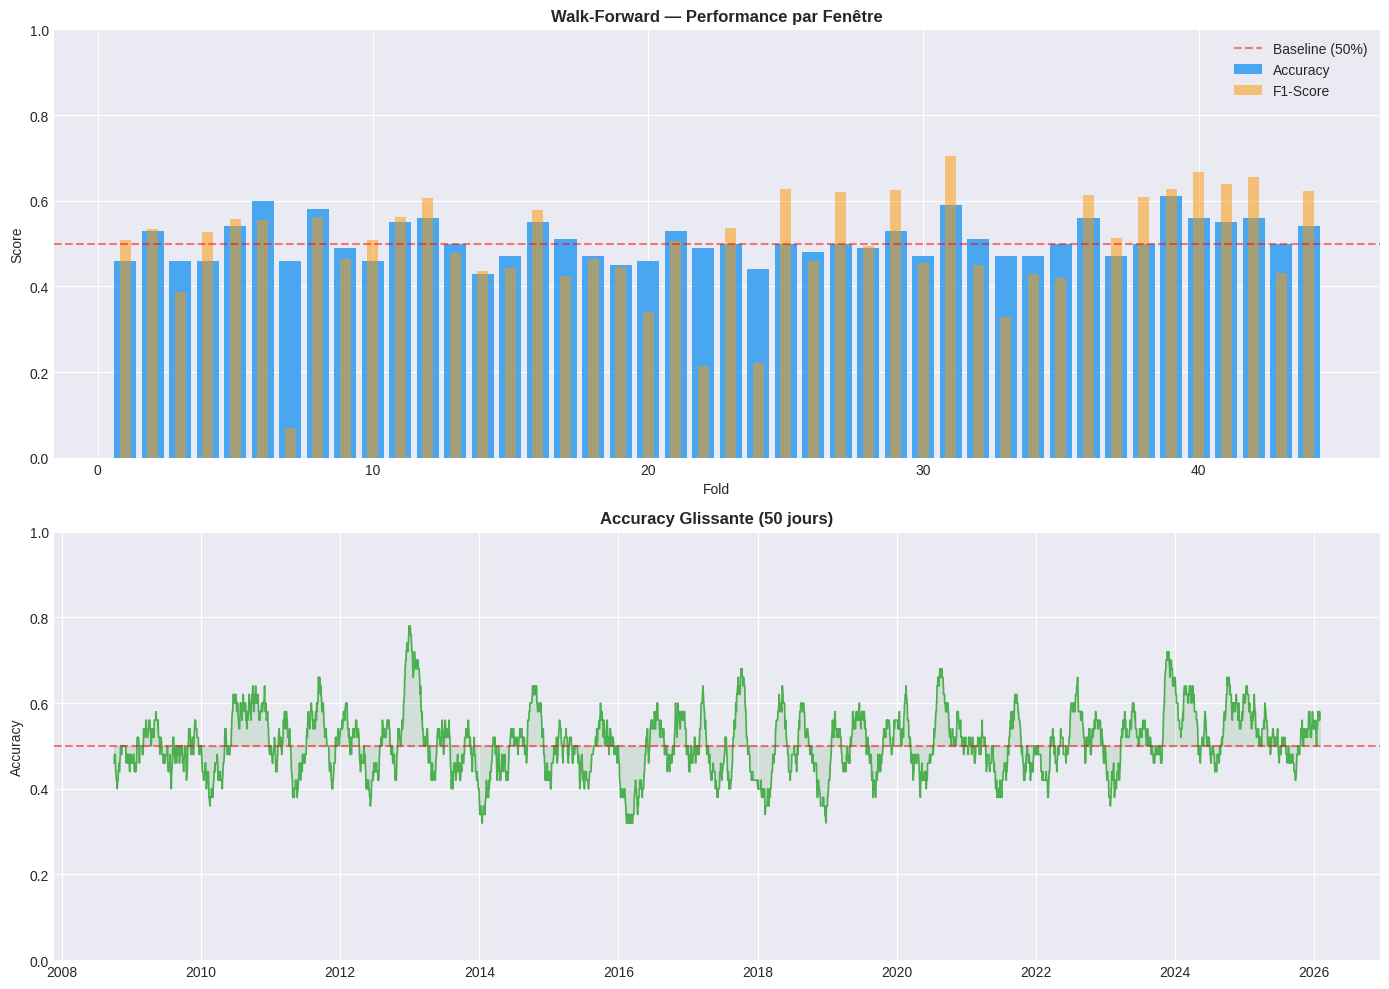

In [33]:
# --- Visualisation Walk-Forward ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Accuracy par fold
ax = axes[0]
ax.bar(wf_results['fold'], wf_results['accuracy'], color='#2196F3', alpha=0.8, label='Accuracy')
ax.bar(wf_results['fold'], wf_results['f1'], color='#FF9800', alpha=0.5, label='F1-Score', width=0.4)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (50%)')
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Walk-Forward — Performance par Fenêtre', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)

# Courbe de prédictions vs réel
ax = axes[1]
wf_df = pd.DataFrame({'date': wf_dates, 'actual': wf_actuals, 'predicted': wf_preds})
wf_df = wf_df.set_index('date')
rolling_acc = (wf_df['actual'] == wf_df['predicted']).rolling(50).mean()
ax.plot(rolling_acc.index, rolling_acc.values, color='#4CAF50', linewidth=1.2)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5)
ax.set_title('Accuracy Glissante (50 jours)', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.fill_between(rolling_acc.index, rolling_acc.values, 0.5, alpha=0.1, color='green')

plt.tight_layout()
plt.show()

## 15. Conclusion & Prochaines Étapes

### Résultats
- Les deux modèles (Random Forest et XGBoost) ont été entraînés et évalués sur des données de prix WTI.
- L'optimisation des hyperparamètres (GridSearch / RandomizedSearch) a permis d'améliorer les performances.
- La gestion du risque (Stop-Loss, Take-Profit, Kelly Criterion) réduit le drawdown au prix d'un rendement parfois plus faible.
- Le Walk-Forward confirme la robustesse (ou non) de la stratégie sur différentes fenêtres temporelles.

### Prochaines Étapes
1. **🔮 Intégrer l'analyse de sentiment** — Ajouter les scores de sentiment comme features supplémentaires
2. **📈 Ajouter d'autres modèles** — LSTM, GRU, Transformer
3. **🧪 Optuna** — Pour une optimisation bayésienne plus efficace des hyperparamètres